# Exploratory Data Analysis — NLP Disaster Tweets

## Introduction

This notebook presents a structured Exploratory Data Analysis (EDA) for the [**NLP Getting Started**](https://www.kaggle.com/competitions/nlp-getting-started) Kaggle competition, which challenges participants to build a model capable of distinguishing real disaster tweets from non-disaster ones.

The dataset consists of **7,613 labeled tweets**, each annotated with a binary target:
- `target = 1` → The tweet describes a **real disaster**.
- `target = 0` → The tweet does **not** describe a real disaster.

Beyond the tweet text, the dataset includes optional metadata fields: `keyword`, `location`, and a unique `id`.

### Goals of this EDA

The analysis is organized into three progressive layers of exploration:

1. **Dataset Overview** — Understand the structure, dimensions, data types, missing values, and class balance.
2. **Text Quality and Cleaning** — Identify duplicates, retweets, empty entries, character/token length distributions, truncation risks, and extract metadata elements (URLs, mentions, hashtags, emojis).
3. **Lexical and Surface-Level Analysis** — Examine n-gram frequencies, the impact of stopword removal, and punctuation/capitalization patterns to uncover discriminative linguistic signals.

By the end of this notebook, we will have a thorough understanding of the data's strengths and limitations, and a set of actionable insights to guide the preprocessing and feature engineering stages of model development.


# **Dataset Overview**
1. **Load and inspect the dataset (Essential)**
    - Tasks: ``shape``, ``head``, ``info``
    - Purpose: understand available fields (text, timestamp, user, location, label, etc.).

In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

In [3]:
# Load the training dataset
data_path = os.path.join('data', 'disaster_tweets', 'train.csv')
disaster_tweets_df = pd.read_csv(data_path)

In [4]:
# Inspect dataset dimensions
print("Dataset shape: ", disaster_tweets_df.shape)

Dataset shape:  (7613, 5)


In [5]:
# Quick Review of the raw data
disaster_tweets_df.head(10)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


We have in the dataset the following Data:
#####  **Key Feature Definitions**

- **id**: A unique identifier assigned to each tweet.
- **keyword**: A specific disaster-related term associated with the tweet (may be null).
- **location**: The user-reported location from which the tweet originated (may be null).
- **text**: The full content of the tweet that contains mentions and hashtags.
- **target**: Our ground truth label; 1 indicates a tweet about a real disaster, while 0 indicates otherwise.

In [6]:
# Check data types and missing values
disaster_tweets_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB


``df.info()`` shows a total of 7,613 records. We can see that ``keyword`` and ``location`` have missing values, while the rest of the columns are complete. All features are stored as either integers or strings.

We can see that most of the null data is in the location column, and with the following simple calculation we can calculate the percentage of null values relative to the total number of records.

Total number of registers: **7613**  
Null values: **2500**

The percentage is computed as:

$$
\frac{2500}{7613} \times 100
$$

$$
= 0.3283 \times 100
$$

$$
= 32.83\%
$$

**Result:** The percentage of null values is approximately **32.83%** of the total records.


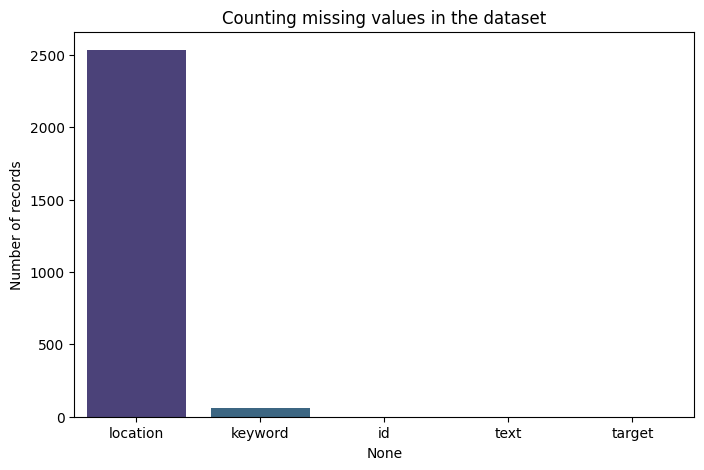

In [7]:
# Calculate missing values per column and sort them in descending order
bar_graph_null_vals = disaster_tweets_df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

# Create the bar plot (x=column names, y=null counts) using a color palette
sns.barplot(x=bar_graph_null_vals.index, y=bar_graph_null_vals.values, palette='viridis', hue=bar_graph_null_vals.index)

plt.title("Counting missing values in the dataset")
plt.ylabel("Number of records")
plt.show()

Given that the null values in the dataset are quite significant, we will explore the location column to determine whether it is important to keep it or remove it entirely in order to save time in processing the data. The first step I consider is to divide the dataset into two DataFrames, one of which contains only the labels Fake Tweet (0) and Real Tweet (1). This information is used to perform a brief analysis to check whether the data is balanced.

In [8]:
target_0_df = disaster_tweets_df[disaster_tweets_df['target'] == 0]
target_1_df = disaster_tweets_df[disaster_tweets_df['target'] == 1]

#####  **Disaster Tweet DataFrame**

In [9]:
target_1_df.sample(5)

,id,keyword,location,text,target
2923,4202,drowned,"R'lyeh, South Pacific",Sadly before she could save humanity Ursula dr...,1
7091,10156,upheaval,Connecticut,A look at state actions a year after Ferguson'...,1
1730,2493,collided,"Traverse City, MI",Bicycle-SUV accident in Mesick: Police say tha...,1
5728,8175,rescuers,NaN,Rescuers are searching for hundreds of migrant...,1
7041,10088,typhoon,NaN,Obama Declares Disaster for Typhoon-Devastated...,1


##### **Not real disaster Tweet DataFrame**

In [10]:
target_0_df.sample(5)

,id,keyword,location,text,target
6179,8815,sirens,Sydney,Marketforce Perth named winner of Sirens round...,0
800,1160,blight,Laventillemoorings,If you dotish to blight your car go right ahea...,0
2924,4203,drowned,taking bath do not disturb,i drowned in the kiddie pool and i lost my ploppy,0
993,1443,body%20bagging,Texas,G+: +https://t.co/dODXi41Y1CåÊis Body Bagging ...,0
4443,6323,hostage,NaN,If you fill your mind with encouragement and p...,0


In [11]:
print("Number of data for each category")
print("Number of record on target 0 (Not Disaster Tweet): ", target_0_df.shape[0])
print("Number of record on target 1 (Disaster Tweet):", target_1_df.shape[0])

Number of data for each category
Number of record on target 0 (Not Disaster Tweet):  4342
Number of record on target 1 (Disaster Tweet): 3271


The current distribution **(57% vs. 43%)** is considered technically balanced for NLP tasks.  Applying artificial balancing to the text can introduce noise, and a difference of 14 points does not significantly skew modern classifiers.

In [12]:
number_null_values_target_0 = target_0_df['location'].isnull().sum()
number_no_null_values_target_0 = target_0_df.shape[0] - number_null_values_target_0

print("Number of null values of location in target 0: ", number_null_values_target_0)
print("Number of not null values of location in target 0: ", number_no_null_values_target_0)

Number of null values of location in target 0:  1458
Number of not null values of location in target 0:  2884


In [13]:
number_null_values_target_1 = target_1_df['location'].isnull().sum()
number_no_null_values_target_1 = target_1_df.shape[0] - number_null_values_target_1
print("Number of null values of location in target 1: ", number_null_values_target_1)
print("Number of not null values of location in target 1: ", number_no_null_values_target_1)

Number of null values of location in target 1:  1075
Number of not null values of location in target 1:  2196


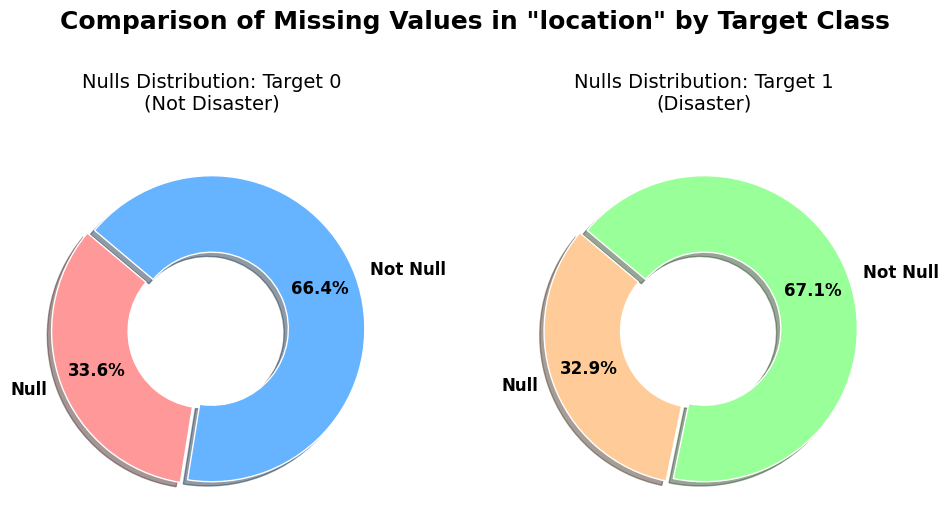

In [14]:
colors_0 = ['#ff9999','#66b3ff']
colors_1 = ['#ffcc99','#99ff99']

values_0 = [number_null_values_target_0, number_no_null_values_target_0]
values_1 = [number_null_values_target_1, number_no_null_values_target_1]

labels = ['Null', 'Not Null']

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

explode = (0.05, 0)
wedge_props = {'width': 0.5, 'edgecolor': 'w'}

# Figure 1: Target 0
ax[0].pie(values_0, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors_0, explode=explode, pctdistance=0.75,
        wedgeprops=wedge_props, shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})
ax[0].set_title('Nulls Distribution: Target 0\n(Not Disaster)', fontsize=14, pad=20)

# Figure 2: Target 1
ax[1].pie(values_1, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors_1, explode=explode, pctdistance=0.75,
        wedgeprops=wedge_props, shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})
ax[1].set_title('Nulls Distribution: Target 1\n(Disaster)', fontsize=14, pad=20)


plt.suptitle('Comparison of Missing Values in "location" by Target Class', 
             fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

In [15]:
print("Most frequent values for the location field")
disaster_tweets_df['location'].value_counts().head(20)

Most frequent values for the location field


location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Australia           18
Chicago, IL         18
California          17
New York, NY        15
California, USA     15
Everywhere          15
San Francisco       14
Name: count, dtype: int64

In [16]:
print("The total number of unique values for locations presented in DataSet:", disaster_tweets_df['location'].value_counts().shape[0])

The total number of unique values for locations presented in DataSet: 3341


After analyzing the distribution of null values segmented by class, it is determined that the feature is not informative for the model for the following reasons:

- **Distribution Invariance:** The proportion of nulls is almost identical in both classes (~33%), demonstrating a lack of correlation between the absence of data and the target.

- **Noise and Sparsity:** As it is a free text field with high variability, its inclusion would generate noise and unnecessarily increase dimensionality without providing real predictive power.

- **Efficiency:** Removal reduces computational cost and allows the model to focus on the semantic signal of the text.

In [17]:
disaster_tweets_df_without_location = disaster_tweets_df.drop(columns=['location'])

2. **Check data types and missing values (Essential)**
    - Tasks: ``dtypes``, ``isnull()``.``sum()``
    - Purpose: identify cleaning and preprocessing needs.

In [18]:
# dtypes is an attribute of a DataFrame
disaster_tweets_df.dtypes

id          int64
keyword       str
location      str
text          str
target      int64
dtype: object

In [19]:
# Return a boolean same-sized object indicating if the values are NA. NA values, such as None or numpy.NaN, gets mapped to True values.
disaster_tweets_df.isnull()

,id,keyword,location,text,target
0,False,True,True,False,False
1,False,True,True,False,False
2,False,True,True,False,False
3,False,True,True,False,False
4,False,True,True,False,False
...,...,...,...,...,...
7608,False,True,True,False,False
7609,False,True,True,False,False
7610,False,True,True,False,False
7611,False,True,True,False,False


In [20]:
# Apply a sum for each column with all data. Obviously a sum operation defined depend of data type
disaster_tweets_df.sum()

id                                                   41429450
keyword     ablazeablazeablazeablazeablazeablazeablazeabla...
location    BirminghamEst. September 2012 - BristolAFRICAP...
text        Our Deeds are the Reason of this #earthquake M...
target                                                   3271
dtype: object

3. **Cardinality and unique values**
    - Tasks: number of unique users, locations, hashtags, labels
    - Purpose: detect dominant users or rare categories.

In [21]:
import re

In [22]:
# I take only one column of the DataFrame accesing with the name of the column, and apply the value_count() attribute and take the attribute shape for obtain the total number of records
# Additionally the value_counts() attribute, take the unique values of the column and count the number of these values
number_unique_users = disaster_tweets_df['id'].value_counts().shape[0]
number_unique_locations = disaster_tweets_df['location'].value_counts().shape[0]
print("Number of unique users", number_unique_users)
print("Number of locations", number_unique_locations)

""" For take the information about the number of unique hashtags, we have to process the data first. First we must take a copy of the text column since DataFrame. 
With text DataSeries, we iterate though the serie and use regultar expresions to find all ocurrences of words that begin with #. 
"""
text_disaster = disaster_tweets_df['text']

def count_and_save_hashtags(text_dataserie):
    hashtags_dataset = []
    number_of_hastags = 0
    for element in text_dataserie:
        number_of_hastags += len(re.findall(r'#\w+', element))
        has_hashtag = re.findall(r'#\w+', element)
        if has_hashtag:
            for hashtag in has_hashtag:
                hashtags_dataset.append(hashtag)
    return hashtags_dataset, number_of_hastags

number_unique_labels = disaster_tweets_df['target'].value_counts().shape[0]

hashtags_dataset, number_of_hastags = count_and_save_hashtags(text_disaster)

print(f"Number of hashtags: ", number_of_hastags)
print("Number of labels: ", number_unique_labels)

hashtags_dataset = pd.Series(hashtags_dataset)

Number of unique users 7613
Number of locations 3341
Number of hashtags:  3330
Number of labels:  2


We have the number of hashtags present in the dataset. In this case, we go a little deeper by looking at the most commonly used hashtags in general using a bar chart and a word cloud.

In [23]:
print("Most frequent values for the hashtags field")
frequent_hashtags = hashtags_dataset.value_counts().head(15)
frequent_hashtags

Most frequent values for the hashtags field


#news          38
#News          38
#hot           31
#prebreak      30
#best          30
#Hiroshima     21
#GBBO          17
#islam         15
#NowPlaying    12
#terrorism     11
#ISIS          11
#nowplaying    10
#Japan         10
#India         10
#BBC           10
Name: count, dtype: int64

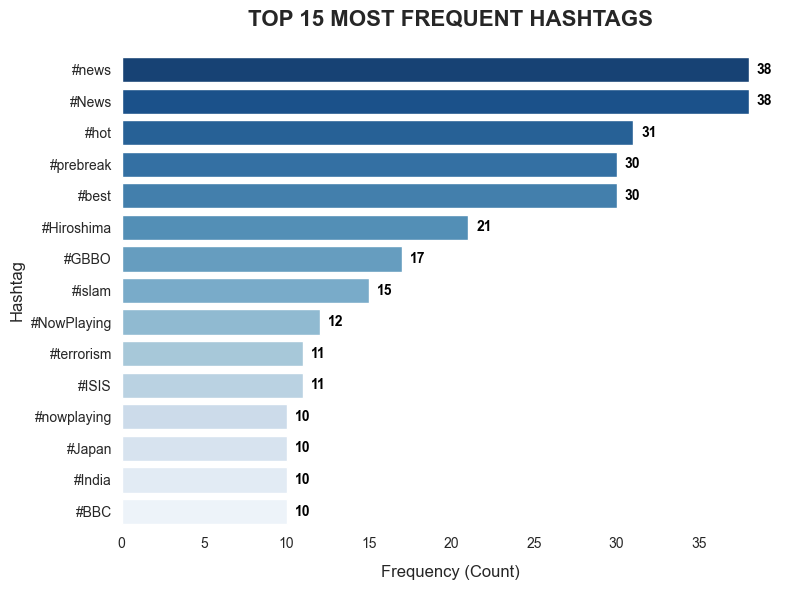

In [24]:
sns.set_style("white") 
fig, ax = plt.subplots(figsize=(8, 6))

pal = sns.color_palette("Blues_r", len(frequent_hashtags))

sns.barplot(
    y=frequent_hashtags.index, 
    x=frequent_hashtags.values, 
    palette=pal,
    hue=frequent_hashtags.index,
    ax=ax
)

for i, v in enumerate(frequent_hashtags.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

ax.set_title('TOP 15 MOST FREQUENT HASHTAGS', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Frequency (Count)', fontsize=12, labelpad=10)
ax.set_ylabel('Hashtag', fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

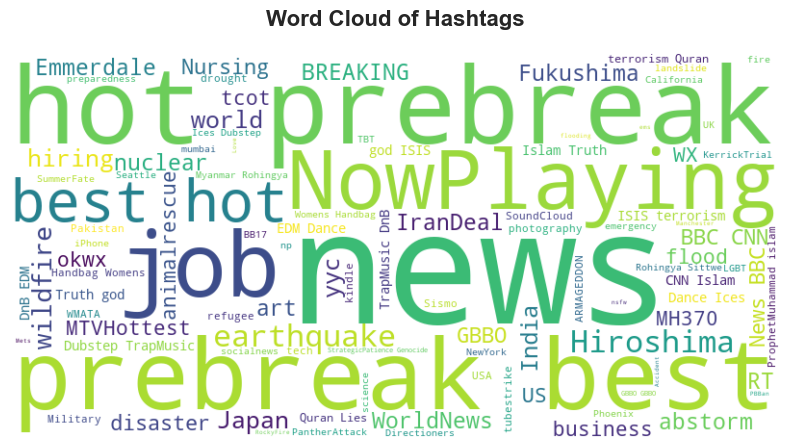

In [25]:
from wordcloud import WordCloud

all_hashtags = ""

for hashtag in hashtags_dataset.values:
    all_hashtags += hashtag

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis',       
    max_words=100,              
    contour_color='steelblue' 
).generate(all_hashtags)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Hashtags", fontsize=16, fontweight='bold', pad=20)
plt.show()

Once the data has been checked in general terms, the number of hashtags for each class in the dataset is analyzed, as well as the most frequently used hashtags for each class.

In [26]:
text_target_0 = target_0_df['text']
text_target_1 = target_1_df['text']

dataset_hashtags_target0, number_hashtags_target0 = count_and_save_hashtags(text_target_0)
dataset_hashtags_target1, number_hashtags_target1 = count_and_save_hashtags(text_target_1)



dataset_hashtags_target0 = pd.Series(dataset_hashtags_target0)
dataset_hashtags_target1 = pd.Series(dataset_hashtags_target1)

print("Most frequent values for the hashtags in target 0 (Not Disaster)")
frequent_hashtags_target0 = dataset_hashtags_target0.value_counts().head(15)
frequent_hashtags_target0

Most frequent values for the hashtags in target 0 (Not Disaster)


#hot             18
#prebreak        17
#best            17
#news            15
#GBBO            13
#islam           11
#NowPlaying      10
#nowplaying      10
#jobs             9
#EDM              8
#DnB              8
#Beyhive          8
#Directioners     8
#RT               7
#Dubstep          7
Name: count, dtype: int64

In [27]:
print("Most frequent values for the hashtags in target 1 (Disaster)")
frequent_hashtags_target1 = dataset_hashtags_target1.value_counts().head(15)
frequent_hashtags_target1

Most frequent values for the hashtags in target 1 (Disaster)


#News          33
#news          23
#Hiroshima     21
#hot           13
#prebreak      13
#best          13
#Japan         10
#India         10
#yyc           10
#Sismo          9
#earthquake     8
#abstorm        8
#terrorism      8
#ISIS           8
#BBC            7
Name: count, dtype: int64

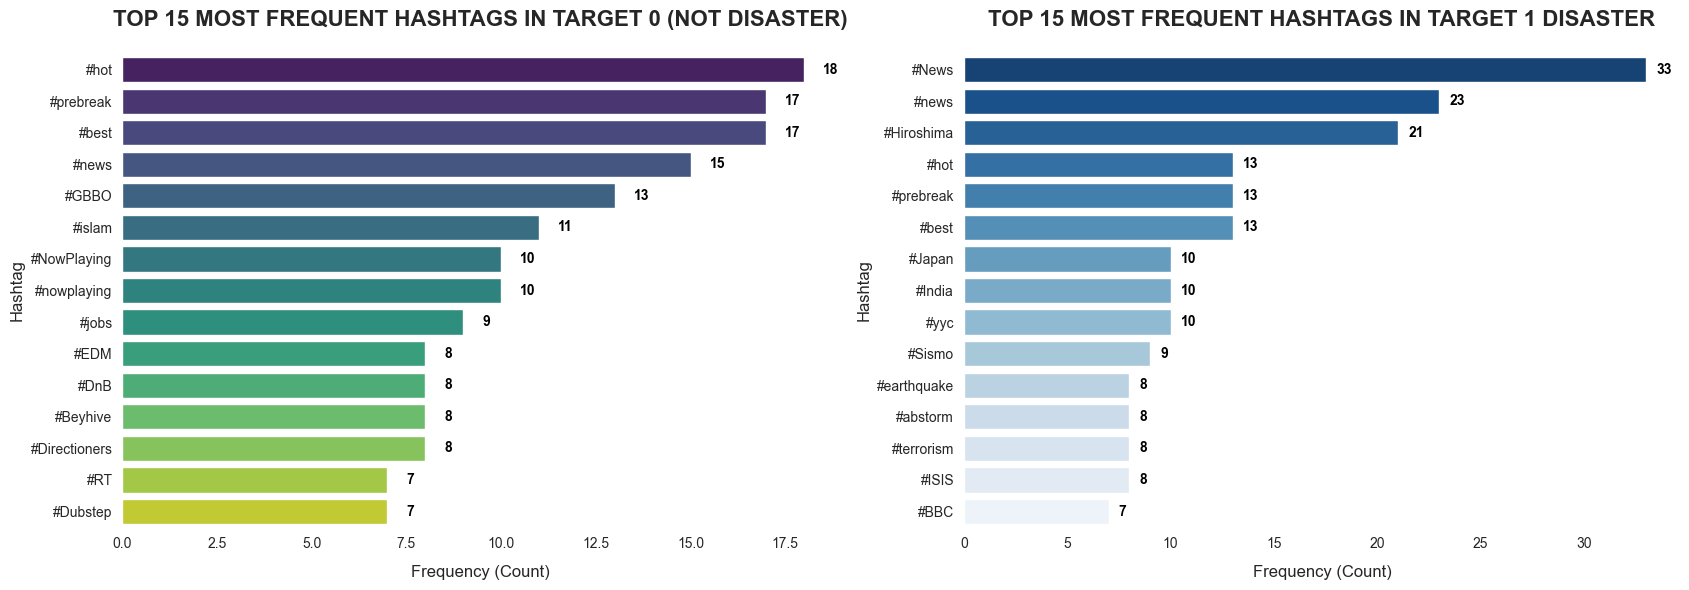

In [28]:
sns.set_style("white") 
fig, ax = plt.subplots(1, 2, figsize=(17, 6))

pal_target0 = sns.color_palette("viridis", len(frequent_hashtags_target0))

pal_target1 = sns.color_palette("Blues_r", len(frequent_hashtags_target1))

sns.barplot(
    y=frequent_hashtags_target0.index, 
    x=frequent_hashtags_target0.values, 
    palette=pal_target0,
    hue=frequent_hashtags_target0.index,
    ax=ax[0]
)

sns.barplot(
    y=frequent_hashtags_target1.index, 
    x=frequent_hashtags_target1.values, 
    palette=pal_target1,
    hue=frequent_hashtags_target1.index,
    ax=ax[1]
)

for i, v in enumerate(frequent_hashtags_target0.values):
    ax[0].text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

for i, v in enumerate(frequent_hashtags_target1.values):
    ax[1].text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

ax[0].set_title('TOP 15 MOST FREQUENT HASHTAGS IN TARGET 0 (NOT DISASTER)', fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel('Frequency (Count)', fontsize=12, labelpad=10)
ax[0].set_ylabel('Hashtag', fontsize=12)

ax[1].set_title('TOP 15 MOST FREQUENT HASHTAGS IN TARGET 1 DISASTER', fontsize=16, fontweight='bold', pad=20)
ax[1].set_xlabel('Frequency (Count)', fontsize=12, labelpad=10)
ax[1].set_ylabel('Hashtag', fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

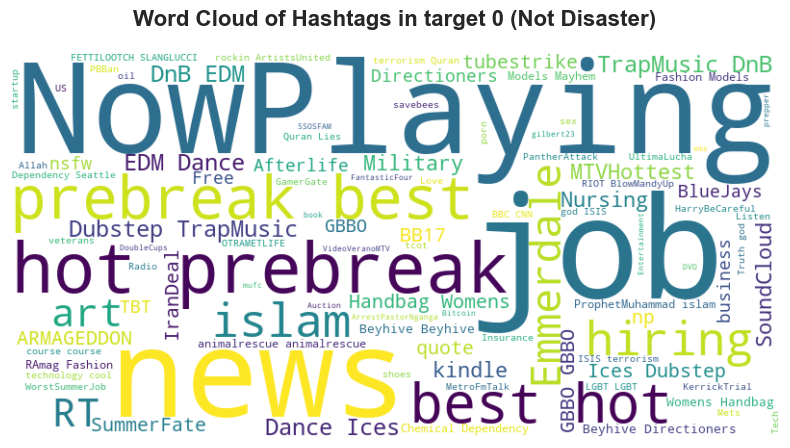

In [29]:
all_hashtags_target0 = ""

for hashtag in dataset_hashtags_target0.values:
    all_hashtags_target0 += hashtag

wordcloud_target0 = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis',       
    max_words=100,              
    contour_color='steelblue' 
).generate(all_hashtags_target0)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_target0, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Hashtags in target 0 (Not Disaster)", fontsize=16, fontweight='bold', pad=20)
plt.show()

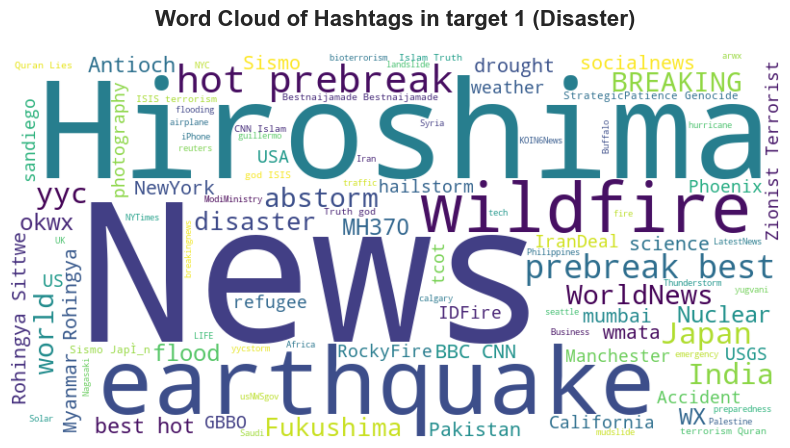

In [30]:
all_hashtags_target1 = ""

for hashtag in dataset_hashtags_target1.values:
    all_hashtags_target1 += hashtag

wordcloud_target1 = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis',       
    max_words=100,              
    contour_color='steelblue' 
).generate(all_hashtags_target1)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_target1, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Hashtags in target 1 (Disaster)", fontsize=16, fontweight='bold', pad=20)
plt.show()

Comparative analysis of hashtags reveals a correlation between the hashtags present in the text and the target variable. While Target 0 is associated with social metrics and employment, Target 1 shows a concentration of crisis terms and geographical events. Therefore, hashtags are validated as high-value discriminative features that must be preserved and normalized during preprocessing.

# **Text Quality and Cleaning**

4. **Duplicate tweets and retweets (Essential)**
    - Tasks: detect duplicate text, flag/remove retweets (RT @)
    - Purpose: prevent bias from highly repeated content.


We take the DataFrame and apply a filter of where values that are True when applying the duplicated attribute.
The parameters do the following: 
- ``subset``: Selects an specific column of the dataset to detect duplicates
- ``keep``: Maintain all duplicated values (We apply this because we want to identify that duplicated records with different targets)

In [31]:
duplicated_df = disaster_tweets_df_without_location[disaster_tweets_df_without_location.duplicated(subset=['text'], keep=False)]
duplicated_df.head(5)

,id,keyword,text,target
40,59,ablaze,Check these out: http://t.co/rOI2NSmEJJ http:/...,0
48,68,ablaze,Check these out: http://t.co/rOI2NSmEJJ http:/...,0
106,156,aftershock,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...,0
115,165,aftershock,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...,0
118,171,aftershock,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/TH...,0


**Investigating Label Inconsistencies:**

Some tweets have identical text but carry different target labels. We'll group them 
by their content and filter for cases where the number of unique targets is greater than 1.
This helps us identify and handle 'noisy' data that could confuse our future model.

In [32]:
duplicated_focus_target = duplicated_df.groupby('text', as_index=False)['target'].nunique()
duplicated_with_multiple_targets = duplicated_focus_target[duplicated_focus_target['target'] > 1]
duplicated_with_multiple_targets.head(5)

,text,target
0,#Allah describes piling up #wealth thinking it...,2
7,#foodscare #offers2go #NestleIndia slips into ...,2
11,.POTUS #StrategicPatience is a strategy for #G...,2
24,CLEARED:incident with injury:I-495 inner loop...,2
25,Caution: breathing may be hazardous to your he...,2


In [33]:
# Removing records with conflicting labels to ensure a cleaner, more consistent training signal.
not_duplicate_text = disaster_tweets_df_without_location[~disaster_tweets_df_without_location['text'].isin(duplicated_with_multiple_targets)]
not_duplicate_text

,id,keyword,text,target
0,1,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...
7608,10869,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,Police investigating after an e-bike collided ...,1


In [34]:
# Drop the records that are Retweets using the string method startswith, to check if the text have RT or @ in the beggining of the text
disaster_tweets_df_cleaned_duplicated = not_duplicate_text
disaster_tweets_df_cleaned_RT = disaster_tweets_df_cleaned_duplicated[~(disaster_tweets_df_cleaned_duplicated['text'].str.startswith('RT') | disaster_tweets_df_cleaned_duplicated['text'].str.startswith('@'))]
disaster_tweets_df_cleaned_RT.sample(10)

,id,keyword,text,target
1630,2354,collapsed,ÛÏ@TheHighFessions: 'My friend came to school...,0
109,159,aftershock,'The harder the conflict the more glorious the...,0
4393,6245,hijacking,#hot Funtenna: hijacking computers to send da...,0
7361,10540,windstorm,Reality Training: Train falls off elevated tra...,1
2246,3216,deluged,Businesses are deluged with invoices. Make you...,0
2565,3680,destroy,Don't let others bring you down no matter how ...,0
192,271,ambulance,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...,0
2836,4080,displaced,Angry Woman Openly Accuses NEMA Of Stealing Re...,1
2800,4027,disaster,Û¢i'm the architect of my own disasterÛ¢,0
2908,4176,drown,Some older Native Australians believe that the...,0


In [35]:
disaster_tweets_df = disaster_tweets_df_cleaned_RT

5. **Missing or empty text entries (Essential)**
    - Tasks: remove or impute empty tweets.


In [36]:
# Counting tweets with a character length of exactly zero
if disaster_tweets_df[disaster_tweets_df['text'].str.len() == 0].shape[0] == 0:
    print("The number of empty tweets are 0")
else:
    print("We have empty tweets")

The number of empty tweets are 0


6. **Tweet length analysis (Essential)**
    - Tasks: character length, token length distributions
    - Purpose: identify outliers and truncation risks.

In [37]:
"""
We take the legth of the characters and show in ascending order to know the records with lower character length.
"""
disaster_tweets_df_length_tokens = disaster_tweets_df.copy()
disaster_tweets_df_length_tokens['character_length'] = disaster_tweets_df_length_tokens['text'].str.len()
disaster_tweets_df_length_tokens.sort_values(by="character_length", ascending=True).head(10)

,id,keyword,text,target,character_length
5115,7295,nuclear%20reactor,Err:509,0,7
4890,6962,massacre,Bad day,0,7
1882,2703,crushed,Crushed,0,7
4971,7088,meltdown,Meltdown,0,8
3670,5224,fatality,fatality,0,8
24,36,NaN,LOOOOOOL,0,8
30,44,NaN,The end!,0,8
28,40,NaN,Cooool :),0,9
3667,5221,fatality,Fatality!,0,9
6705,9605,thunder,Thunder???,0,10


In [38]:
# Computing word counts (tokens) by splitting the text on whitespace
disaster_tweets_df_length_tokens['tokens_length'] = disaster_tweets_df_length_tokens['text'].apply(lambda x: len(x.split()))
disaster_tweets_df_length_tokens.sort_values(by="tokens_length", ascending=True).head(5)

,id,keyword,text,target,character_length,tokens_length
1882,2703,crushed,Crushed,0,7,1
4971,7088,meltdown,Meltdown,0,8,1
5115,7295,nuclear%20reactor,Err:509,0,7,1
5184,7400,obliterated,Obliterated,0,11,1
6705,9605,thunder,Thunder???,0,10,1


An analysis of the characters and tokens present in each category is performed to check the distributions of each characteristic.

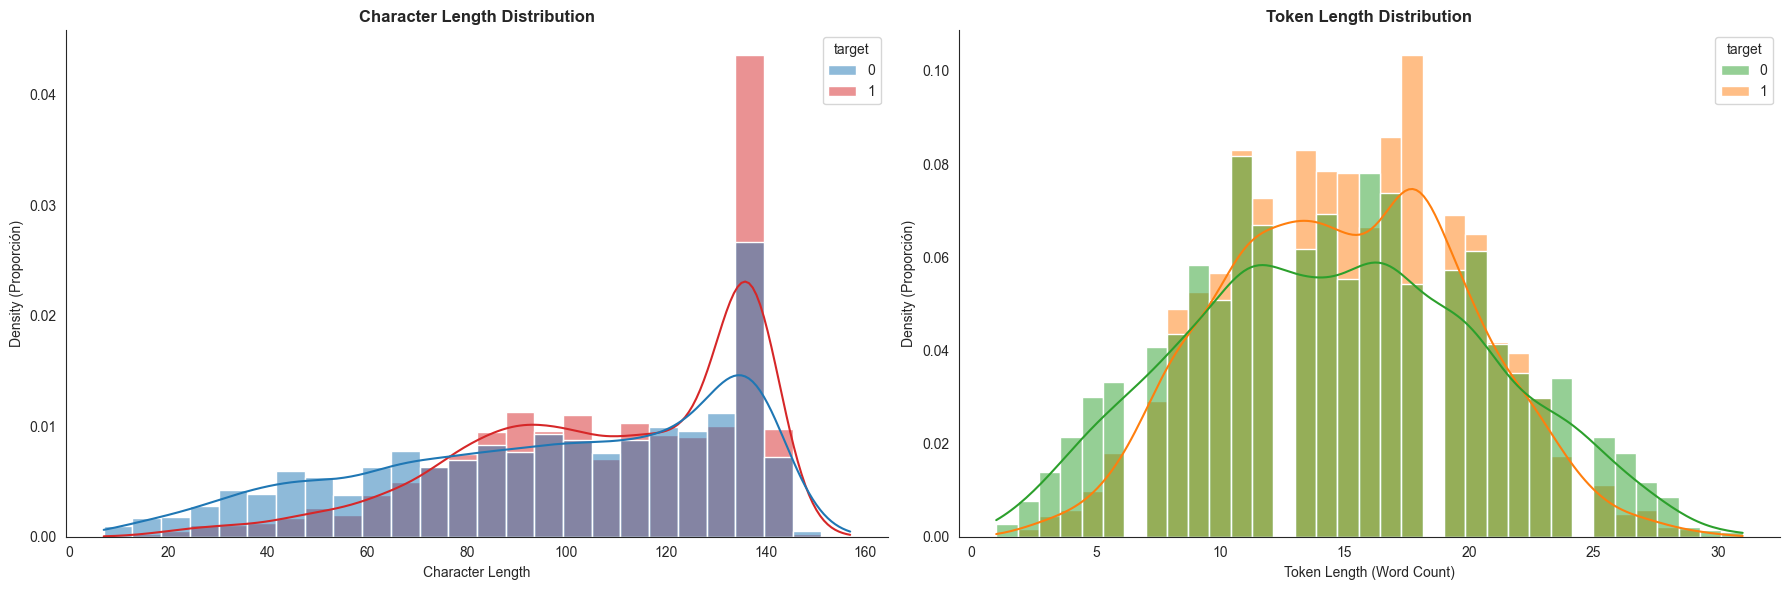

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(
    data=disaster_tweets_df_length_tokens, 
    x='character_length', 
    hue='target', 
    kde=True,
    stat='density',
    common_norm=False,
    palette=['#1f77b4', '#d62728'],
    alpha=0.5,
    ax=ax[0]
)
ax[0].set_title("Character Length Distribution", fontweight='bold')
ax[0].set_xlabel("Character Length")
ax[0].set_ylabel("Density (Proporción)")

sns.histplot(
    data=disaster_tweets_df_length_tokens, 
    x='tokens_length', 
    hue='target', 
    kde=True,
    stat='density',
    common_norm=False,
    palette=['#2ca02c', '#ff7f0e'],
    alpha=0.5,
    ax=ax[1]
)
ax[1].set_title("Token Length Distribution", fontweight='bold')
ax[1].set_xlabel("Token Length (Word Count)")
ax[1].set_ylabel("Density (Proporción)")

sns.despine()   
plt.tight_layout()
plt.show()

**Length Distribution Analysis & Truncation Risk**

Length distribution analysis and truncation risk
Visual analysis of text length reveals a contrast in user behavior between the two categories. While non-disaster-related tweets show a widely dispersed character count, disaster-related records show an aggressive spike just before the 140-character mark. This clustering, coupled with a consistent density between 12 and 20 tokens, suggests that emergency reports are inherently more structured and tend to reach Twitter's historical length limit. Consequently, this exposes the dataset to a risk of truncation. Therefore, it is necessary to inspect records within the range of 130 to 145 characters to verify whether semantic signals were cut off and replaced by broken URLs or ellipses. 

In [40]:
mask_long = (disaster_tweets_df_length_tokens['character_length'] >= 130) & (disaster_tweets_df_length_tokens['character_length'] <= 145)
truncated_tweets = disaster_tweets_df_length_tokens[mask_long & (disaster_tweets_df_length_tokens['target'] == 1)]

for text in truncated_tweets['text'].head(10):
    print(text)
    print("-" * 50)

All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
--------------------------------------------------
Barbados #Bridgetown JAMAICA ÛÒ Two cars set ablaze: SANTA CRUZ ÛÓ Head of the St Elizabeth Police Superintende...  http://t.co/wDUEaj8Q4J
--------------------------------------------------
#Kurds trampling on Turkmen flag later set it ablaze while others vandalized offices of Turkmen Front in #Diyala http://t.co/4IzFdYC3cg
--------------------------------------------------
How the West was burned: Thousands of wildfires ablaze in #California alone http://t.co/iCSjGZ9tE1 #climate #energy http://t.co/9FxmN0l0Bd
--------------------------------------------------
Reported motor vehicle accident in Curry on Herman Rd near Stephenson involving an overturned vehicle. Please use... http://t.co/YbJezKuRW1
--------------------------------------------------
#TruckCrash Overturns On #FortWorth Interstate http://t

Direct inspection of the records confirmed that tweets close to the historical 140-character limit are truncated, often accompanied by the automatic injection of URLs and HTML encoding noise. Therefore, preserving them in the raw text poses a risk, as the model may falsely correlate the presence of a link (http...) with the occurrence of a critical event, ignoring the actual context. Consequently, implementing Regex cleaning is useful for preprocessing. By decoding HTML and removing automated metadata such as links and user mentions, we force the model to focus exclusively on the natural language describing the emergency.

7. **URLs, mentions, hashtags, emojis extraction**
    - Tasks: extract and count each element separately
    - Purpose: these are often informative features.

In [41]:
import html

def clean_text(text):
    # Decode HTML entities (e.g., & becomes &)
    text = html.unescape(text)
    
    # Remove URLs (catches http://, https://, and www.)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove mentions of users (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove multiple spaces and leave a single space
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [42]:
disaster_tweets_df['clean_text'] = disaster_tweets_df['text'].apply(clean_text)
disaster_tweets_df[['text', 'clean_text']].sample(5)

,text,clean_text
1697,When high fashion and food collide http://t.co...,When high fashion and food collide
3551,'Food crematoria' provoke outrage amid crisis ...,'Food crematoria' provoke outrage amid crisis ...
1119,.@Vagersedolla visits villages recently bombed...,. visits villages recently bombed by Turkey an...
1264,Fire burning on Pendleton has burned 300 acres...,Fire burning on Pendleton has burned 300 acres...
1531,Russian nuclear-biological-chemical (NBC) brig...,Russian nuclear-biological-chemical (NBC) brig...


In [43]:
import emoji

def find_emojis(text):
    return [c for c in text if emoji.is_emoji(c)]

def has_emojis(text):
    if find_emojis(text):
        return True
    else:
        return False

In [44]:
"""
We apply regular expresions to determine if the record contain an url, mentions, hashtags and emojis and how many for each of one.
"""
disaster_tweets_df['url_count'] = disaster_tweets_df['text'].str.findall(r'https?://\S+|www\.\S+')
disaster_tweets_df['url_count'] = disaster_tweets_df['url_count'].apply(len)
disaster_tweets_df['mentions_count'] = disaster_tweets_df['text'].str.findall(r'@\w+')
disaster_tweets_df['mentions_count'] = disaster_tweets_df['mentions_count'].apply(len)
disaster_tweets_df['hashtags_count'] = disaster_tweets_df['text'].str.findall(r'#\w+')
disaster_tweets_df['hashtags_count'] = disaster_tweets_df['hashtags_count'].apply(len)
disaster_tweets_df['emoji_count'] = disaster_tweets_df['text'].apply(find_emojis)
disaster_tweets_df['emoji_count'] = disaster_tweets_df['emoji_count'].apply(len)
disaster_tweets_df.sample(5)

,id,keyword,text,target,clean_text,url_count,mentions_count,hashtags_count,emoji_count
4140,5887,harm,sticks and stones may break my bones\nbut word...,0,sticks and stones may break my bones but words...,0,0,0,0
2116,3042,death,VIDEO: Slain Mexican Journalist Unknowingly Pr...,0,VIDEO: Slain Mexican Journalist Unknowingly Pr...,1,1,0,0
6127,8743,siren,Today is Corii Siren's birthday! Spoil her now...,0,Today is Corii Siren's birthday! Spoil her now...,2,0,1,0
3452,4936,exploded,Reasons @BlueWestlo has exploded on @YouTube #...,0,Reasons has exploded on #38745:,1,2,1,0
3309,4740,evacuate,myGC: Broken powerlines evacuate Gold Coast tr...,1,myGC: Broken powerlines evacuate Gold Coast tr...,1,0,0,0


In [45]:
target_0_df = disaster_tweets_df[disaster_tweets_df['target'] == 0]
target_1_df = disaster_tweets_df[disaster_tweets_df['target'] == 1]

In [46]:
def counts_hashtags_mentions_url(dataset):
    url_count = dataset['url_count'].sum()
    mentions_count = dataset['mentions_count'].sum()
    hashtags_count = dataset['hashtags_count'].sum()
    return [url_count, mentions_count, hashtags_count]

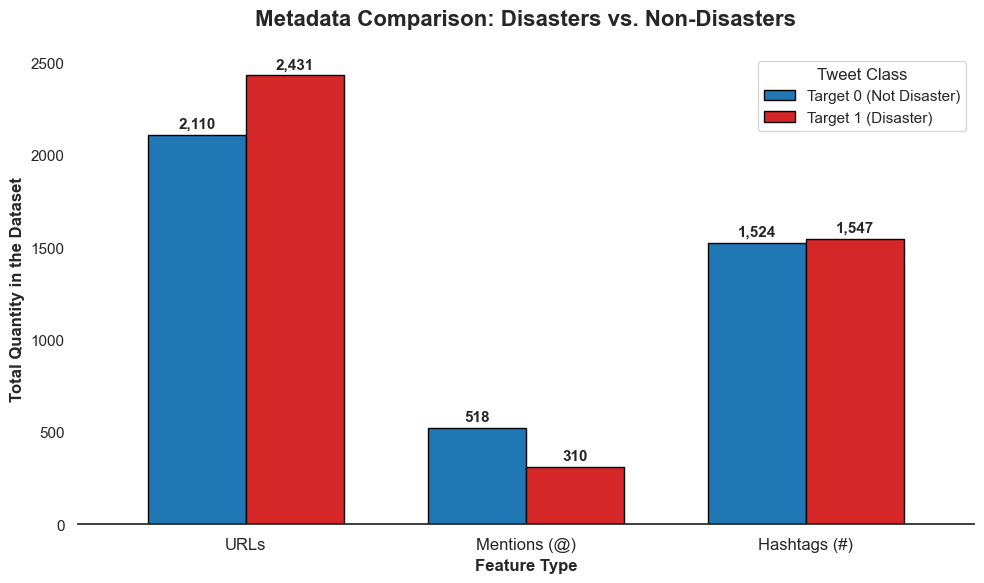

In [47]:
counts_0 = counts_hashtags_mentions_url(target_0_df)
counts_1 = counts_hashtags_mentions_url(target_1_df)

df_comparison = pd.DataFrame({
    'URLs': [counts_0[0], counts_1[0]],
    'Mentions (@)': [counts_0[1], counts_1[1]],
    'Hashtags (#)': [counts_0[2], counts_1[2]]
}, index=['Target 0 (Not Disaster)', 'Target 1 (Disaster)'])

sns.set_theme(style="white", context="notebook")

# The data (.T) is transposed so that the characteristics are on the X-axis.
ax = df_comparison.T.plot(kind='bar', figsize=(10, 6), 
                           color=['#1f77b4', '#d62728'], 
                           edgecolor='black', width=0.7)

# Add data labels above each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8),
                textcoords='offset points', fontweight='bold', fontsize=11)

plt.title('Metadata Comparison: Disasters vs. Non-Disasters', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Feature Type', fontsize=12, fontweight='bold')
plt.ylabel('Total Quantity in the Dataset', fontsize=12, fontweight='bold')

plt.xticks(rotation=0, fontsize=12) 

plt.legend(title='Tweet Class', fontsize=11, title_fontsize=12)
sns.despine(left=True)

plt.tight_layout()
plt.show()


Comparative analysis of metadata reveals differences for each class. Disaster-related tweets show a significantly higher volume of URLs, corroborating the hypothesis that these records often function as automated news alerts or formal reports. In contrast, non-disaster-related tweets show a significantly higher concentration of user mentions, reflecting a more conversational and social communication style. Interestingly, the total frequency of hashtags is almost identical in both categories, indicating that the predictive power of hashtags lies exclusively in their semantic content and not in their volume.

# 3. Lexical and Surface-Level Analysis

8. **Unigram, bigram, trigram frequency analysis (Essential)**
    - Tasks: compute top n-grams overall and per class
    - Purpose: identify disaster-related vocabulary.


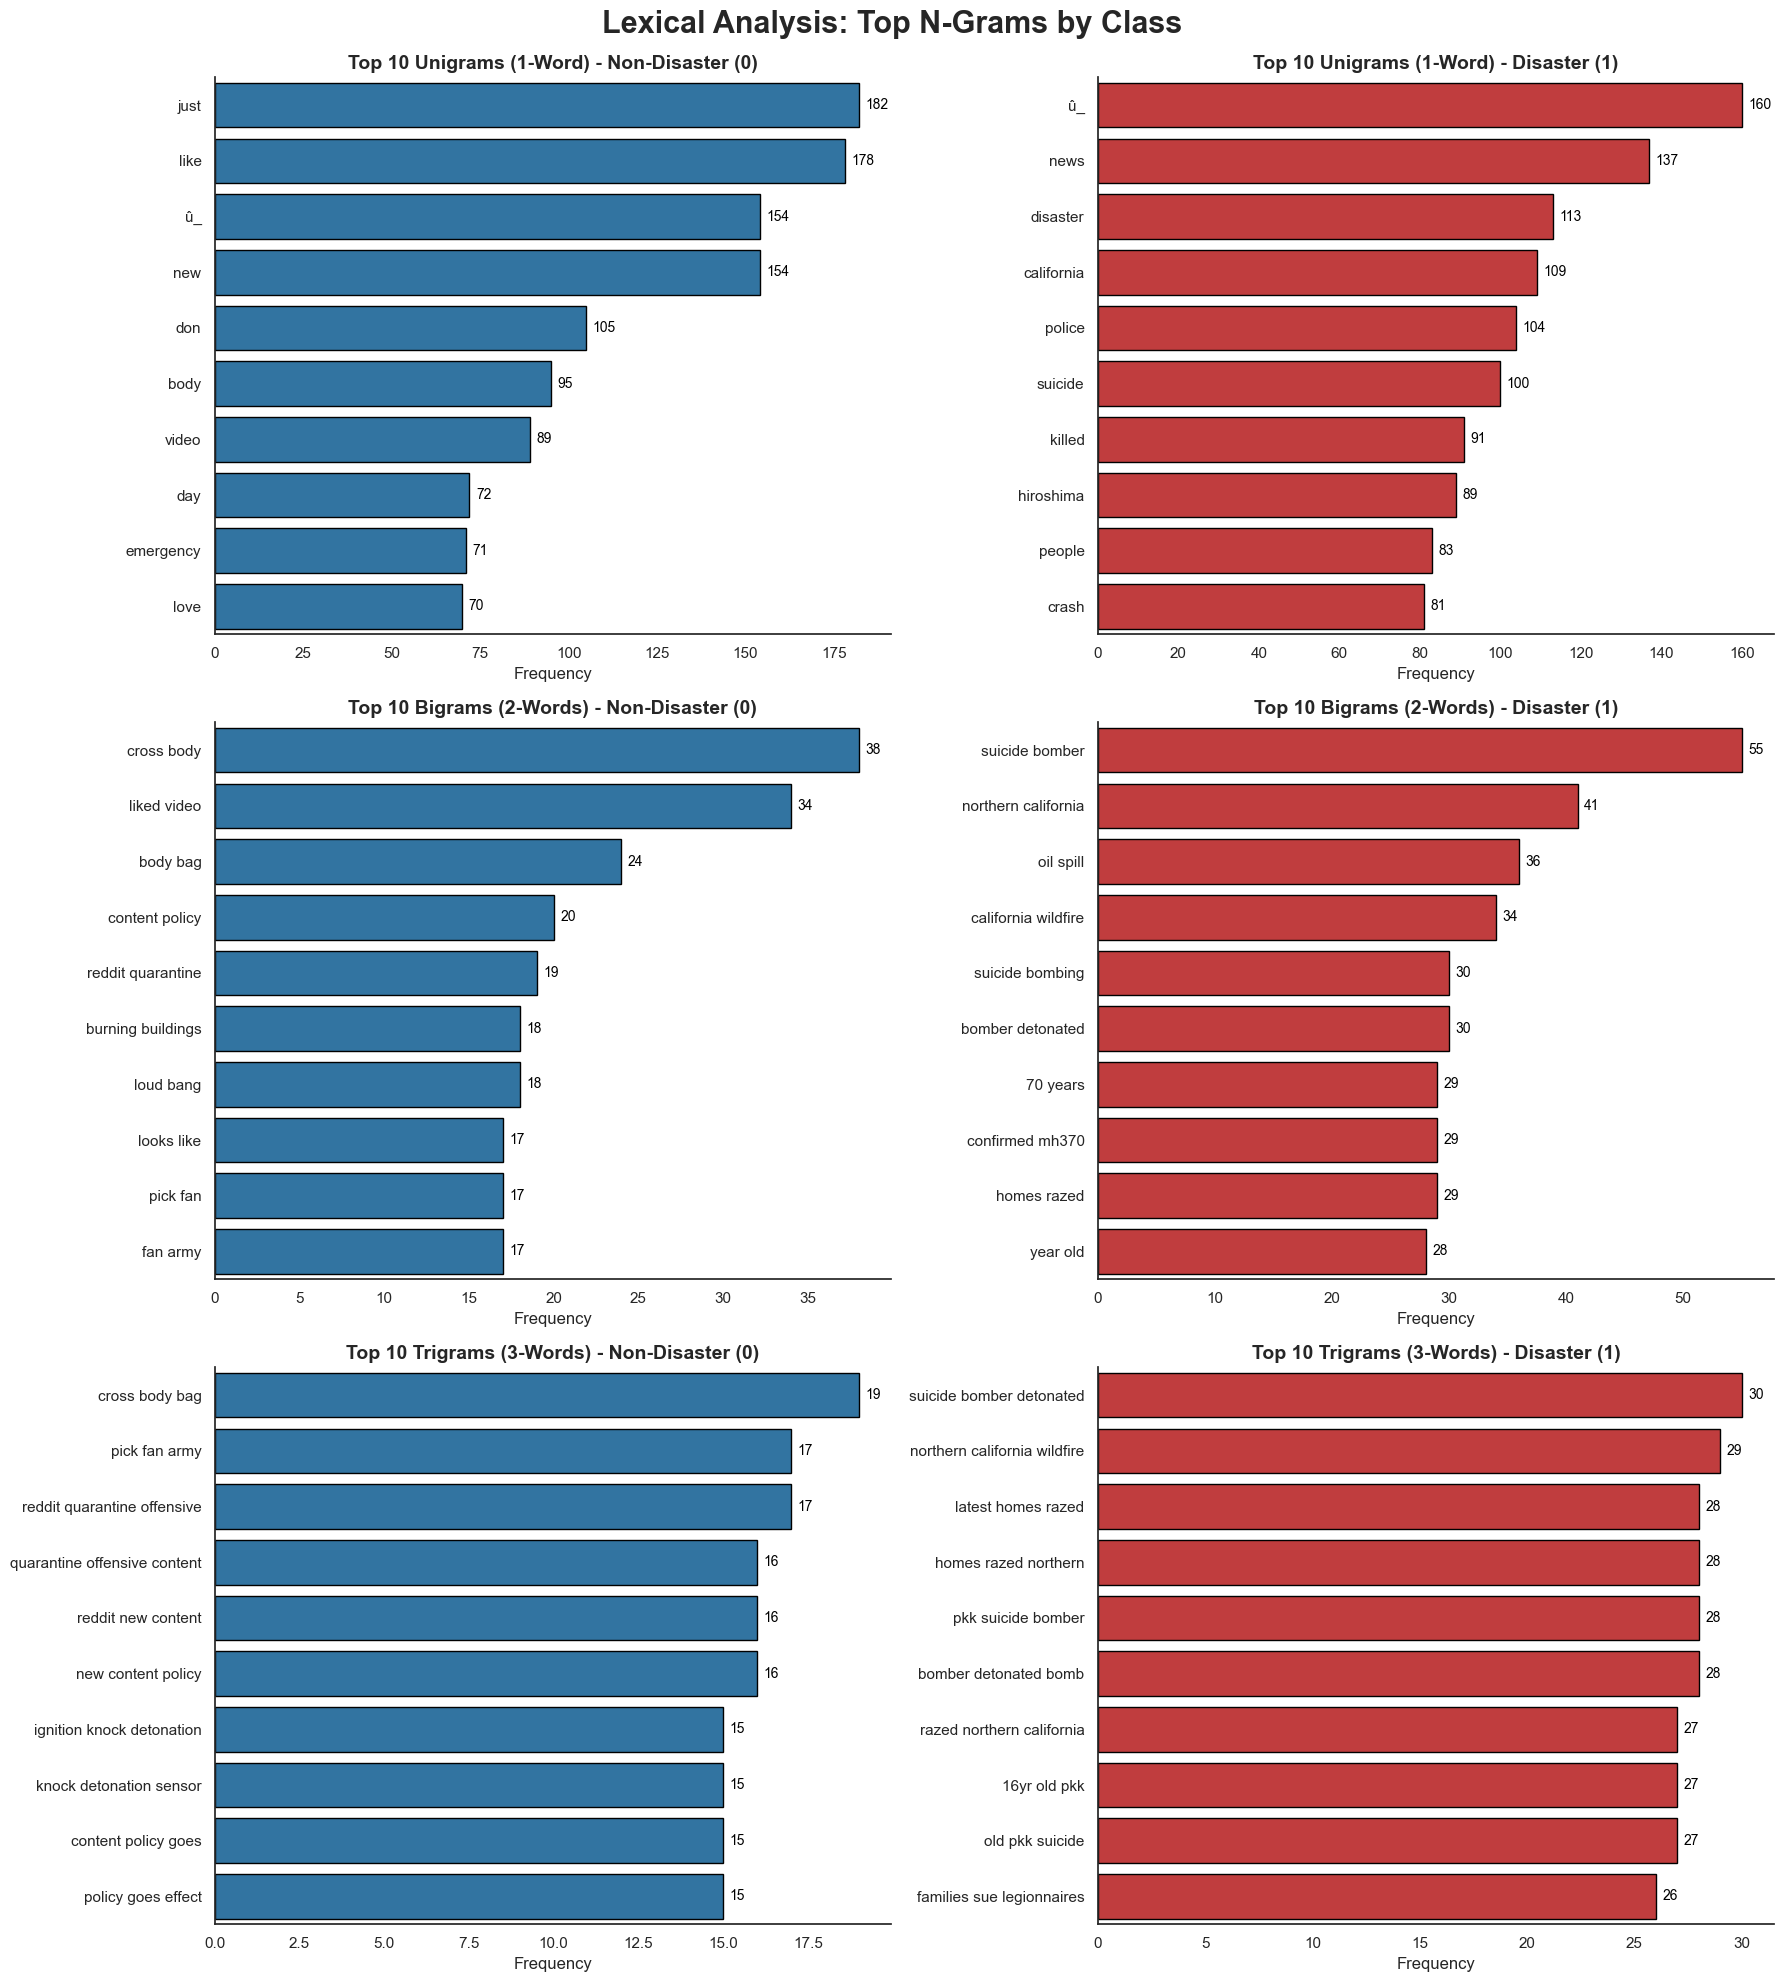

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams_comparative(df, text_col='clean_text', n=15):

    fig, axes = plt.subplots(3, 2, figsize=(18, 20))
    fig.suptitle('Lexical Analysis: Top N-Grams by Class', fontsize=22, fontweight='bold', y=0.99)
    
    # Define N-gram ranges and their titles
    ngram_configs = [
        ((1, 1), 'Unigrams (1-Word)'),
        ((2, 2), 'Bigrams (2-Words)'),
        ((3, 3), 'Trigrams (3-Words)')
    ]
    
    for row, (ng_range, title) in enumerate(ngram_configs):
        for col, target_val in enumerate([0, 1]):
            # Filter the corpus by class and drop nulls for safety
            corpus = df[df['target'] == target_val][text_col].dropna()
            
            vec = CountVectorizer(ngram_range=ng_range, stop_words='english').fit(corpus)
            bag_of_words = vec.transform(corpus)
            sum_words = bag_of_words.sum(axis=0) 
            
            # Sort frequencies in descending order
            words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
            words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]
            
            # Separate words and counts for plotting
            words = [x[0] for x in words_freq]
            counts = [x[1] for x in words_freq]
            
            # Plotting the horizontal bar chart
            color = '#1f77b4' if target_val == 0 else '#d62728'
            ax = axes[row, col]
            sns.barplot(x=counts, y=words, ax=ax, color=color, edgecolor='black')
            
            target_name = "Non-Disaster (0)" if target_val == 0 else "Disaster (1)"
            ax.set_title(f'Top {n} {title} - {target_name}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Frequency')
            ax.set_ylabel('')
            
            for i, v in enumerate(counts):
                ax.text(v + (max(counts) * 0.01), i, str(v), color='black', va='center', fontsize=10)

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_top_ngrams_comparative(disaster_tweets_df, text_col='clean_text', n=10)

The n-gram distributions confirm a distance between the two classes. Target 0 is dominated by colloquial Internet usage, e-commerce, and platform-specific discussions. In contrast, Target 1 shows a very factual and journalistic vocabulary focused on specific events. In addition, bigram and trigram levels resolve the ambiguities of unigrams; for example, for the word “body” in Target 0, it refers to fashion accessories, not fatalities. However, the analysis also highlights the presence of discrepancies in non-disaster-related situations (e.g., buildings on fire) and exposes a persistent coding artifact (û_) that appears frequently in both classes, requiring a specific final cleaning step before model training.

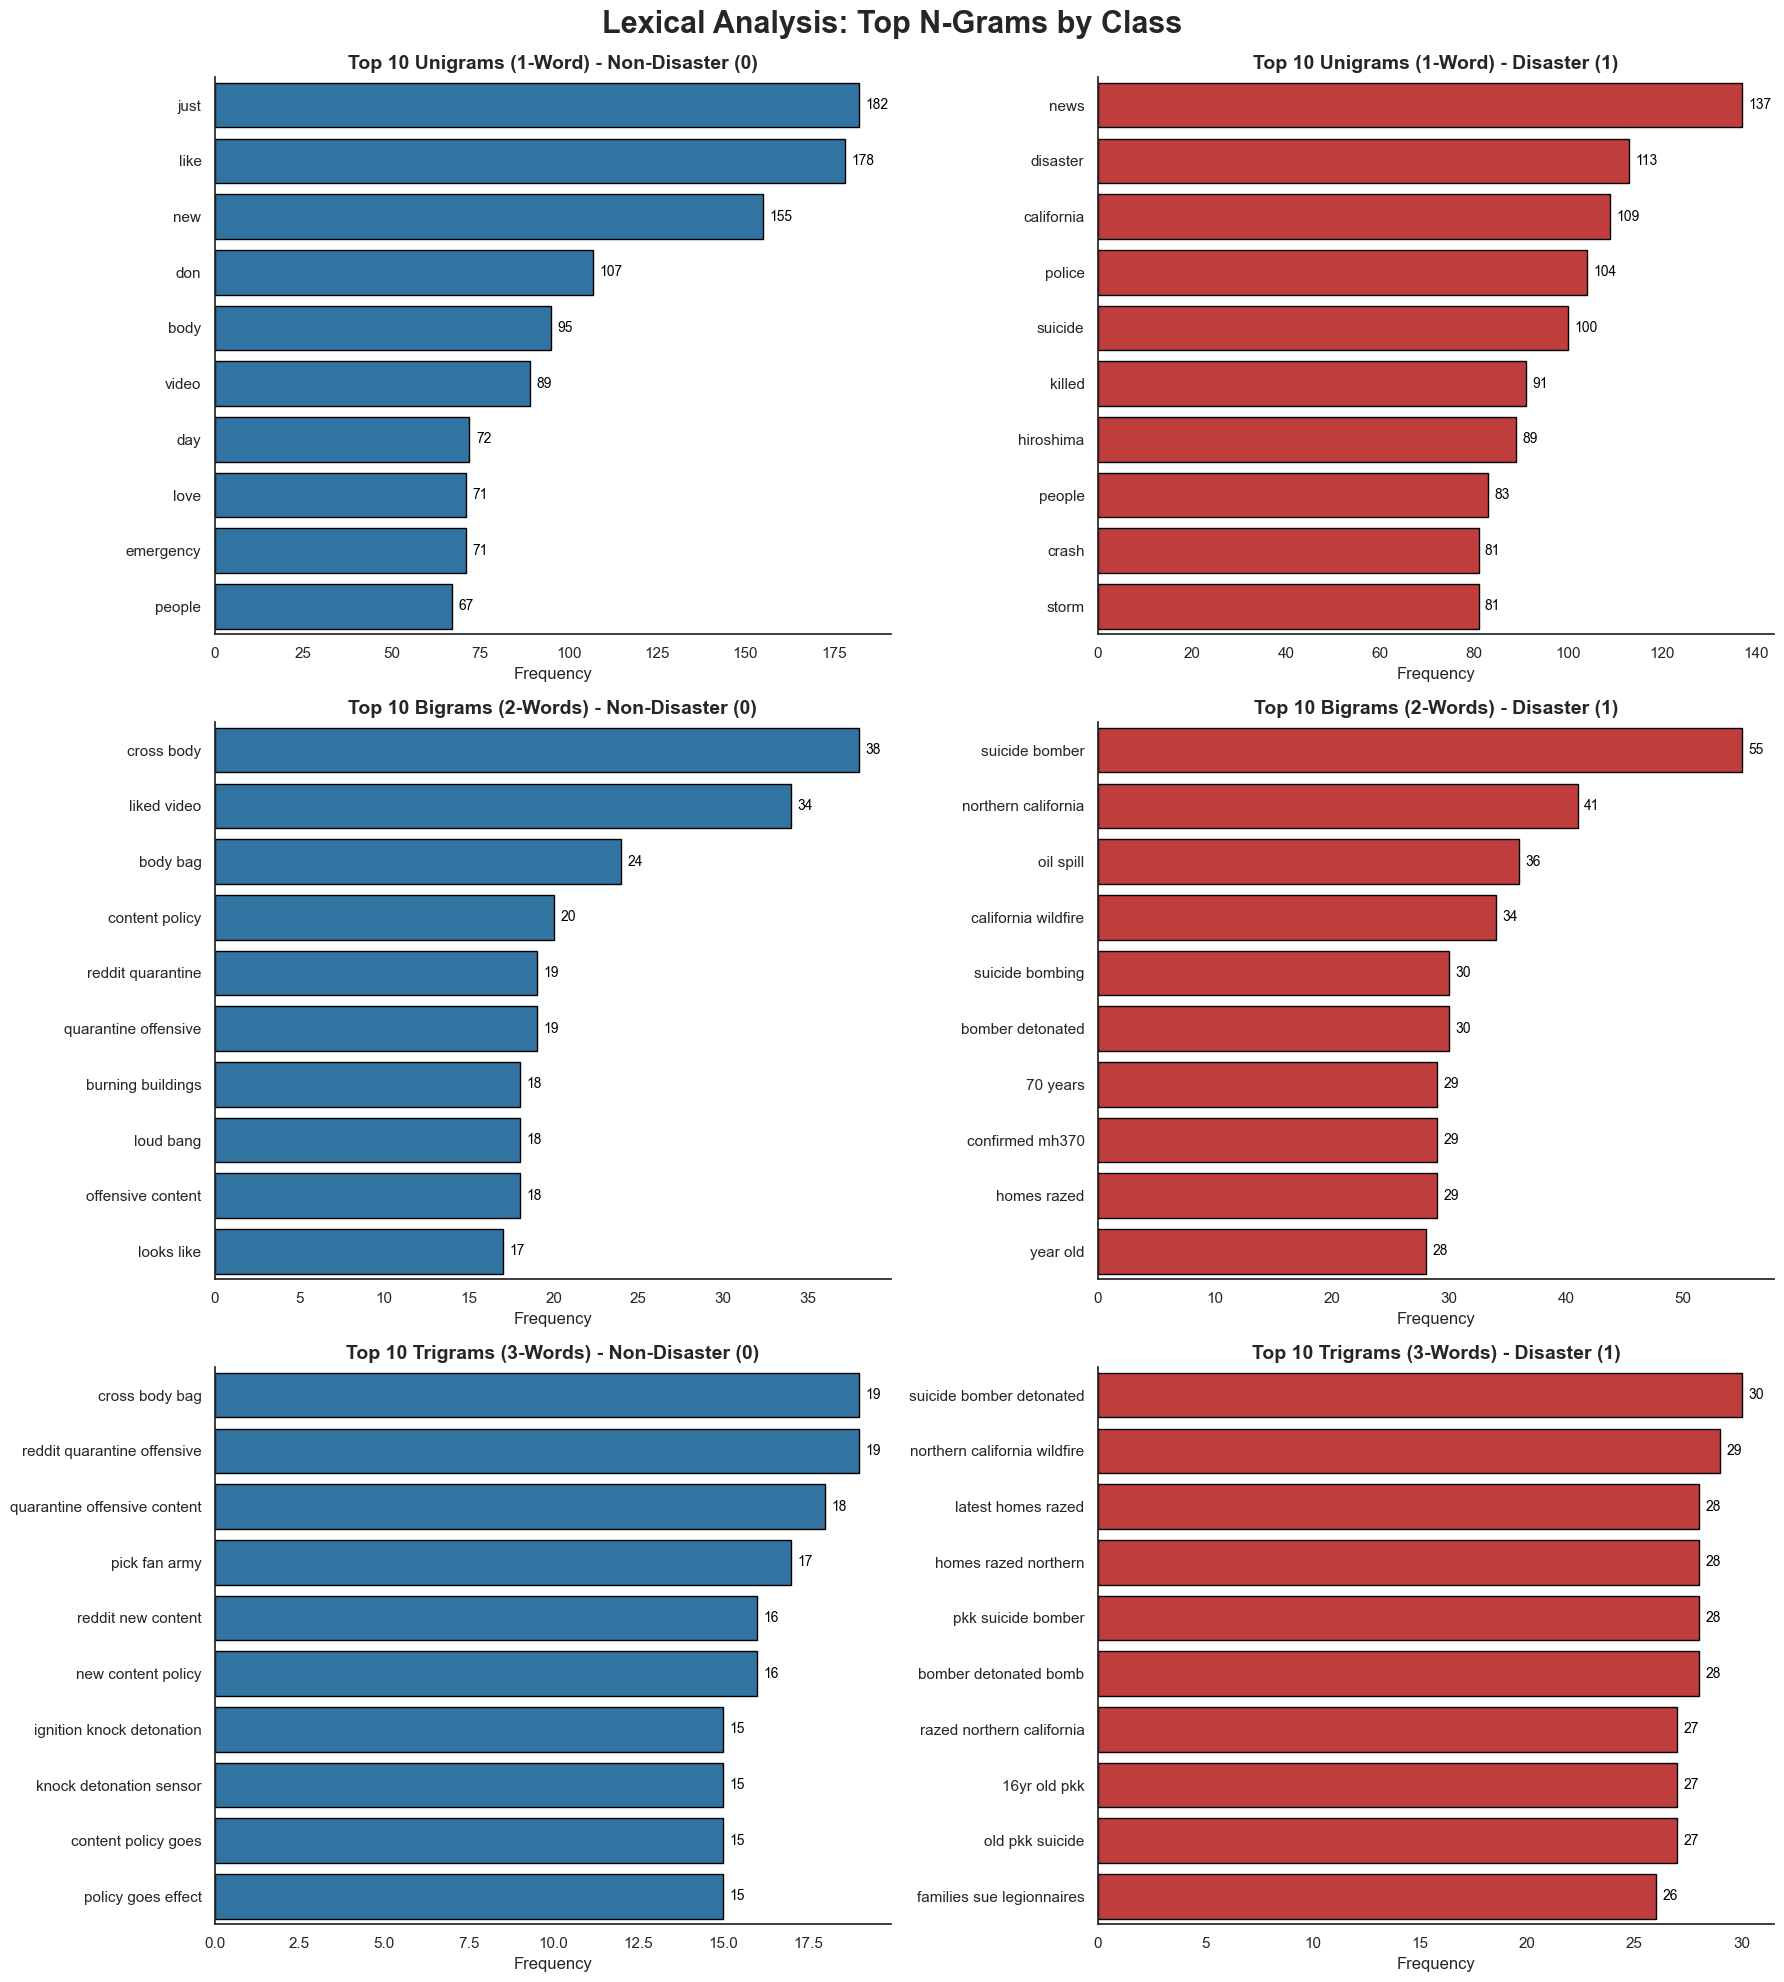

In [49]:
def remove_encoding_artifacts(text):
    # Remove any characters that are NOT in the basic ASCII alphabet
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    
    # Remove underscores ‘_’
    text = re.sub(r'_', ' ', text)
    
    # Remove stray special characters that are left floating around
    text = re.sub(r'(?<!\w)[^\w\s](?!\w)', ' ', text)
    
    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

disaster_tweets_df['clean_text'] = disaster_tweets_df['clean_text'].apply(remove_encoding_artifacts)
plot_top_ngrams_comparative(disaster_tweets_df, text_col='clean_text', n=10)

9. **Stopword vs content-word comparison**
- Tasks: analyze impact of stopword removal.

Total Vocabulary (With Stopwords): 13,143 unique words
Content Vocabulary (Without Stopwords): 12,877 unique words
--------------------------------------------------


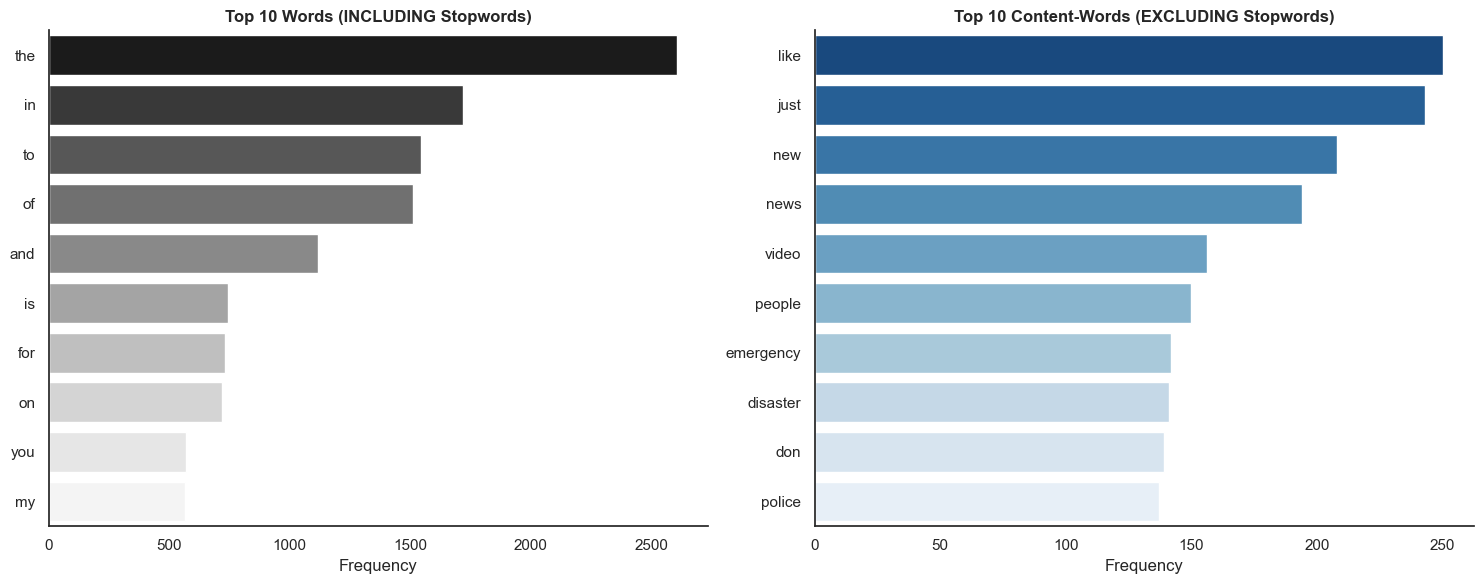

In [50]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stopword_impact(df, text_col='clean_text'):
    corpus = df[text_col].dropna()
    
    # Vectorization with Stopwords
    vec_all = CountVectorizer()
    X_all = vec_all.fit_transform(corpus)
    vocab_all = len(vec_all.vocabulary_)
    
    sum_words_all = X_all.sum(axis=0)
    words_freq_all = [(word, sum_words_all[0, idx]) for word, idx in vec_all.vocabulary_.items()]
    top_words_all = sorted(words_freq_all, key=lambda x: x[1], reverse=True)[:10]
    
    # Vectorization without Stopwords
    vec_content = CountVectorizer(stop_words='english')
    X_content = vec_content.fit_transform(corpus)
    vocab_content = len(vec_content.vocabulary_)
    
    sum_words_content = X_content.sum(axis=0)
    words_freq_content = [(word, sum_words_content[0, idx]) for word, idx in vec_content.vocabulary_.items()]
    top_words_content = sorted(words_freq_content, key=lambda x: x[1], reverse=True)[:10]

    print(f"Total Vocabulary (With Stopwords): {vocab_all:,} unique words")
    print(f"Content Vocabulary (Without Stopwords): {vocab_content:,} unique words")
    print("-" * 50)
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    sns.set_theme(style="whitegrid", context="notebook")

    x_all = [x[1] for x in top_words_all]
    y_all = [x[0] for x in top_words_all]
    
    x_content = [x[1] for x in top_words_content]
    y_content = [x[0] for x in top_words_content]
    
    # Chart 1: With Stopwords
    sns.barplot(x=x_all, y=y_all, ax=ax[0], hue=y_all, palette="Greys_r", legend=False)
    ax[0].set_title('Top 10 Words (INCLUDING Stopwords)', fontweight='bold')
    ax[0].set_xlabel('Frequency')
    
    # Chart 2: Without Stopwords
    sns.barplot(x=x_content, y=y_content, ax=ax[1], hue=y_content, palette="Blues_r", legend=False)
    ax[1].set_title('Top 10 Content-Words (EXCLUDING Stopwords)', fontweight='bold')
    ax[1].set_xlabel('Frequency')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

analyze_stopword_impact(disaster_tweets_df, text_col='clean_text')

The visual comparison between the raw vocabulary and the filtered vocabulary of content words clearly demonstrates the need to remove stop words for this predictive task. When evaluating the raw text, the frequency distribution is overwhelmingly dominated by semantically empty grammatical tokens (e.g., “the,” “in,” “to,” “of”), with the top token exceeding 2,500 occurrences. If retained, these extremely high-frequency terms would introduce a lot of noise, forcing the classification algorithm to assign undue weights.

Conversely, excluding English stopwords successfully reveals good semantic drivers within our corpus. The filtered distribution brings context-rich vocabulary to the fore, highlighting terms such as “news,” “emergency,” “disaster,” and “police.” 

10. **Punctuation and capitalization patterns**
- Tasks: count exclamation marks, question marks, uppercase ratio
- Purpose: signals urgency and emotional intensity.

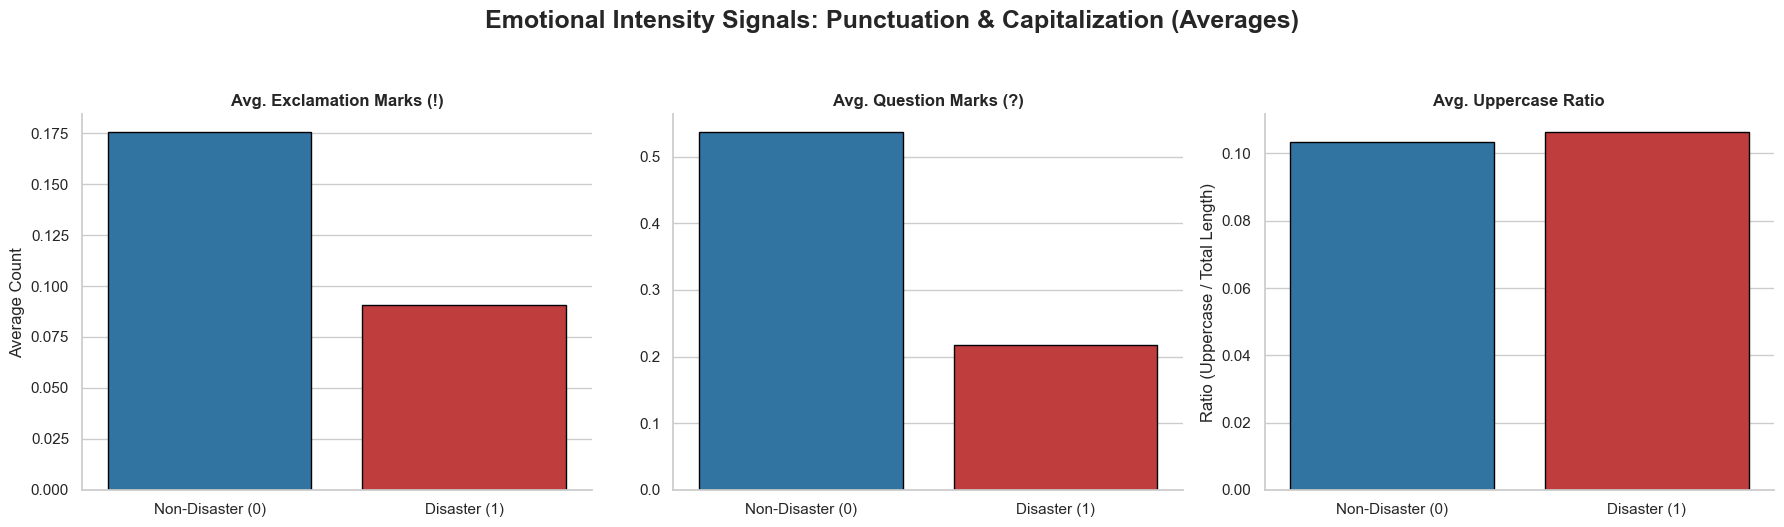

In [51]:
# Count exact occurrences using simple regular expressions
disaster_tweets_df['exclamation_count'] = disaster_tweets_df['text'].str.count(r'!')
disaster_tweets_df['question_count'] = disaster_tweets_df['text'].str.count(r'\?')

def calc_uppercase_ratio(text):
    if len(text) == 0: return 0
    uppercase_chars = sum(1 for c in text if c.isupper())
    return uppercase_chars / len(text)

disaster_tweets_df['uppercase_ratio'] = disaster_tweets_df['text'].apply(calc_uppercase_ratio)

# Group by target and calculate the mean of each feature
stats_df = disaster_tweets_df.groupby('target')[['exclamation_count', 'question_count', 'uppercase_ratio']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Emotional Intensity Signals: Punctuation & Capitalization (Averages)', fontsize=18, fontweight='bold', y=1.05)

sns.set_theme(style="whitegrid", context="notebook")
colors = ['#1f77b4', '#d62728']

# Plot 1: Exclamation Marks (!)
sns.barplot(data=stats_df, x='target', y='exclamation_count', hue='target', palette=colors, ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Avg. Exclamation Marks (!)', fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Disaster (0)', 'Disaster (1)'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Count')

# Plot 2: Question Marks (?)
sns.barplot(data=stats_df, x='target', y='question_count', hue='target', palette=colors, ax=axes[1], edgecolor='black', legend=False)
axes[1].set_title('Avg. Question Marks (?)', fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Disaster (0)', 'Disaster (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Plot 3: Uppercase Ratio
sns.barplot(data=stats_df, x='target', y='uppercase_ratio', hue='target', palette=colors, ax=axes[2], edgecolor='black', legend=False)
axes[2].set_title('Avg. Uppercase Ratio', fontweight='bold')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Non-Disaster (0)', 'Disaster (1)'])
axes[2].set_xlabel('')
axes[2].set_ylabel('Ratio (Uppercase / Total Length)')

sns.despine()
plt.tight_layout()
plt.show()

Visual analysis of punctuation patterns and capitalization provides insights into the structural tone of the dataset. Contrary to the intuitive assumption that emergencies lead to more exclamation marks, the data reveals that tweets unrelated to disasters use them almost twice as often.  Furthermore, the prevalence of question marks in Objective 0 confirms a conversational, peer-to-peer communication style. Meanwhile, the proportion of capital letters shows a subtle but clear increase within the disaster category, corroborating the presence of journalistic markers in capital letters (e.g., “BREAKING NEWS:,” “URGENT:”).

In [54]:
disaster_tweets_df.sample(5)

,id,keyword,text,target,clean_text,url_count,mentions_count,hashtags_count,emoji_count,exclamation_count,question_count,uppercase_ratio
1875,2694,crush,tiffanyfrizzell has a crush: http://t.co/RaF73...,0,tiffanyfrizzell has a crush:,1,0,0,0,0,0,0.058824
247,352,annihilation,annihilating quarterstaff of annihilation,1,annihilating quarterstaff of annihilation,0,0,0,0,0,0,0.000000
6175,8806,sirens,To ouvindo sleeping with sirens awn,0,To ouvindo sleeping with sirens awn,0,0,0,0,0,0,0.028571
6856,9828,trauma,Butt Trauma Extraordinaire,1,Butt Trauma Extraordinaire,0,0,0,0,0,0,0.115385
3971,5645,flooding,ÛÏ@BBCEngland: A burst water main causes majo...,1,A burst water main causes major flooding at a ...,2,1,0,0,0,0,0.140741


---

## Conclusion

This EDA revealed a rich set of patterns that clearly differentiate real disaster tweets from non-disaster ones. Below is a summary of the key findings across each analytical layer:

### Dataset Overview
- The dataset contains **7,613 tweets** across 5 columns. The `location` field has ~33% missing values equally distributed across both classes, making it uninformative for classification — it was dropped.
- The class distribution is **57% non-disaster vs. 43% disaster**, a mild imbalance that does not require artificial rebalancing for modern NLP classifiers.

### Text Quality and Cleaning
- A number of duplicate tweets were found with **conflicting labels**, introducing label noise that was resolved by removing those records.
- Tweets near the historical **140-character limit** were found to be systematically truncated, often containing injected URLs and HTML encoding artifacts — a truncation risk that must be handled in preprocessing.
- No empty tweets were found in the dataset.
- Disaster tweets contain significantly **more URLs**, consistent with automated news alerts or formal reporting, while non-disaster tweets use more **@mentions**, reflecting casual social interaction.

### Lexical and Surface-Level Analysis
- **N-gram analysis** confirmed a strong lexical separation: disaster tweets use factual, journalistic vocabulary (specific events, locations, crisis terms), whereas non-disaster tweets are dominated by colloquial, platform-specific language.
- **Hashtag analysis** corroborated this — disaster-class hashtags cluster around crisis events and geography, while non-disaster hashtags reflect social and commercial topics.
- **Stopword removal** is clearly necessary: without it, semantically empty words overwhelm the frequency distributions and mask the informative content words.
- Contrary to intuition, **non-disaster tweets use exclamation marks more frequently** than disaster ones. Disaster tweets, however, show a higher **uppercase ratio**, suggesting urgency expressed through capitalization rather than punctuation.

### Key Takeaways for Modeling
| Finding | Recommended Action |
|---|---|
| `location` column is uninformative | Drop from feature set |
| Conflicting-label duplicates | Remove before training |
| URLs and HTML entities in text | Strip with regex in text cleaning |
| Truncated tweets with noise | Handle truncation artifacts |
| Hashtags are discriminative | Consider as an auxiliary feature |
| URL count differs by class | Include as a numeric feature |
| Uppercase ratio differs by class | Include as a numeric feature |
